In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData

lambda_A = [
    3745, 3843, 3941, 4039, 4137, 4235, 4333, 4431, 4529, 4627,
    4725, 4823, 4921, 5019, 5117, 5215, 5313, 5411, 5509, 5607,
    5705, 5807, 5909, 6011, 6113, 6215, 6317, 6419, 6521, 6623,
    6725, 6827, 6929, 7031, 7071, 7111, 7151, 7191, 7231, 7271,
    7311, 7351, 7391, 7431, 7471, 7511, 7551, 7591, 7631, 7671, 7711
]

I = [
    0.008333333333, 0.01458333333, 0.02083333333, 0.025, 0.03125,
    0.04166666667, 0.05208333333, 0.06666666667, 0.07916666667, 0.0875,
    0.1, 0.1145833333, 0.1291666667, 0.14375, 0.1583333333, 0.175,
    0.1875, 0.2, 0.2208333333, 0.2520833333, 0.2541666667, 0.26875,
    0.3104166667, 0.31875, 0.3125, 0.3145833333, 0.3145833333, 0.3166666667,
    0.31875, 0.3208333333, 0.3208333333, 0.31875, 0.3166666667, 0.3125,
    0.3083333333, 0.30625, 0.3041666667, 0.3, 0.2958333333, 0.2895833333,
    0.2583333333, 0.1916666667, 0.1104166667, 0.04583333333, 0.01875,
    0.008333333333, 0.004166666667, 0.002083333333, 0.002083333333, 0.002083333333, 0.002083333333
]

df = pd.DataFrame({
    'lambda_A': lambda_A,
    'lambda_A_err': 5,
    'J': I,
    'J_err': 0.001
})

df['lambda_nm'] = df['lambda_A'] / 10.0
df['lambda_nm_err'] = df['lambda_A_err'] / 10.0
df['E_ph'] = 1240 / df['lambda_nm']

print(f"Dataset GaAsP: {len(df)} punti")
print(f"Intervallo λ: {df['lambda_nm'].min():.1f} - {df['lambda_nm'].max():.1f} nm")
print(f"Intervallo E_ph: {df['E_ph'].max():.3f} - {df['E_ph'].min():.3f} eV")

Dataset GaAsP: 51 punti
Intervallo λ: 374.5 - 771.1 nm
Intervallo E_ph: 3.311 - 1.608 eV


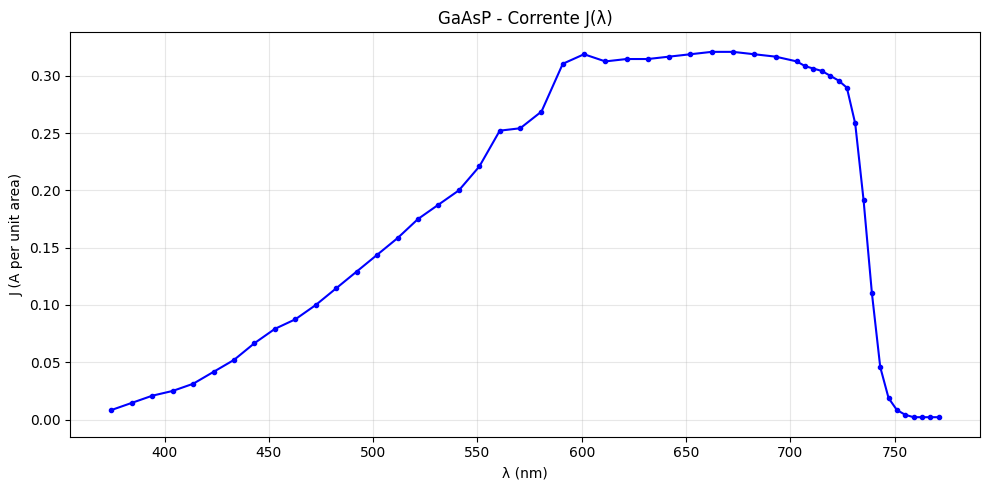

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(df['lambda_nm'], df['J'], 'o-', color='blue', markersize=3)
plt.errorbar(df['lambda_nm'], df['J'], yerr=df['J_err'], fmt='none', ecolor='blue', alpha=0.5)
plt.xlabel('λ (nm)')
plt.ylabel('J (A per unit area)')
plt.title('GaAsP - Corrente J(λ)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:

P_ua_list = [
    0.1057692308, 0.1442307692, 0.1923076923, 0.2403846154, 0.3461538462,
    0.3653846154, 0.4134615385, 0.4326923077, 0.4903846154, 0.5192307692,
    0.5480769231, 0.6057692308, 0.6346153846, 0.6923076923, 0.7307692308,
    0.7596153846, 0.7980769231, 0.8846153846, 0.9615384615, 1.0,
    1.038461538, 1.173076923, 1.192307692, 1.153846154, 1.153846154,
    1.134615385, 1.115384615, 1.153846154, 1.173076923, 1.134615385,
    1.153846154, 1.153846154, 1.153846154, 1.153846154, 1.134615385,
    1.096153846, 1.057692308, 1.038461538, 1.057692308, 1.173076923,
    1.057692308, 0.9615384615, 0.8942307692, 0.8653846154, 0.8461538462,
    0.8076923077, 0.8653846154, 0.8846153846, 0.9230769231, 0.9807692308,
    1.057692308, 1.153846154, 1.201923077, 1.230769231, 1.25,
    1.326923077, 1.307692308, 1.346153846, 1.365384615, 1.346153846,
    1.384615385, 1.403846154, 1.413461538, 1.557692308, 1.884615385,
    2.326923077, 2.576923077, 2.442307692, 2.173076923, 1.980769231,
    1.846153846, 1.769230769, 1.692307692, 1.653846154, 1.634615385,
    1.615384615, 1.596153846, 1.576923077, 1.567307692, 1.557692308,
    1.538461538, 1.557692308, 1.519230769, 1.490384615, 1.5,
    1.442307692, 1.480769231, 1.471153846, 1.461538462, 1.451923077,
    1.442307692, 1.432692308, 1.423076923, 1.442307692, 1.403846154,
    1.384615385, 1.375, 1.375, 1.375, 1.365384615,
    1.346153846, 1.336538462, 1.365384615, 1.346153846, 1.346153846
]

lambda_source = [
    3843, 3941, 4039, 4137, 4235, 4333, 4431, 4529, 4627, 4725,
    4823, 4921, 5019, 5117, 5215, 5313, 5411, 5509, 5607, 5705,
    5807, 5909, 6011, 6113, 6215, 6317, 6419, 6521, 6623, 6725,
    6827, 6929, 7031, 7133, 7235, 7337, 7439, 7541, 7643, 7745,
    7847, 7949, 8051, 8153, 8255, 8357, 8459, 8561, 8663, 8765,
    8867, 8969, 9071, 9122, 9173, 9224, 9275, 9326, 9377, 9428,
    9479, 9530, 9581, 9632, 9683, 9734, 9785, 9836, 9887, 9938,
    9989, 10040, 10091, 10142, 10193, 10244, 10295, 10346, 10397,
    10448, 10499, 10550, 10601, 10652, 10703, 10754, 10805, 10856,
    10907, 10958, 11009, 11060, 11111, 11162, 11213, 11264, 11315,
    11366, 11417, 11468, 11519, 11570, 11621, 11672, 11723
]

df_source = pd.DataFrame({
    'lambda_nm': np.array(lambda_source) / 10.0,
    'P_ua': P_ua_list,
    'P_ua_err': 0.001
})

from scipy.interpolate import interp1d
f_P = interp1d(df_source['lambda_nm'], df_source['P_ua'], kind='linear', fill_value='extrapolate')
f_P_err = interp1d(df_source['lambda_nm'], df_source['P_ua_err'], kind='linear', fill_value='extrapolate')

df['P_ua'] = f_P(df['lambda_nm'])
df['P_ua_err'] = f_P_err(df['lambda_nm'])
df['R'] = df['J'] / df['P_ua']
df['R_err'] = df['R'] * np.sqrt((df['J_err']/df['J'])**2 + (df['P_ua_err']/df['P_ua'])**2)

print("\nRapporto J/P_ua calcolato per GaAsP")


Rapporto J/P_ua calcolato per GaAsP


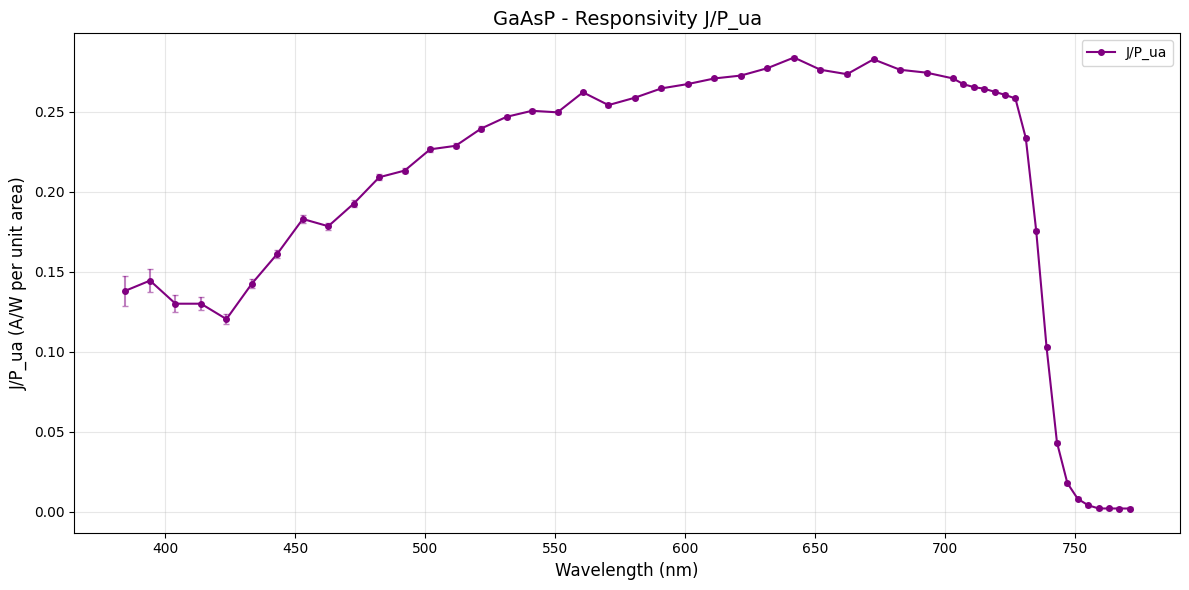


Statistiche rapporto J/P_ua:
   Max = 0.2839
   Min = 0.0019
   Mean = 0.1924
   at λ_max = 631.7 nm


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

lambda_A = [
    3745, 3843, 3941, 4039, 4137, 4235, 4333, 4431, 4529, 4627,
    4725, 4823, 4921, 5019, 5117, 5215, 5313, 5411, 5509, 5607,
    5705, 5807, 5909, 6011, 6113, 6215, 6317, 6419, 6521, 6623,
    6725, 6827, 6929, 7031, 7071, 7111, 7151, 7191, 7231, 7271,
    7311, 7351, 7391, 7431, 7471, 7511, 7551, 7591, 7631, 7671, 7711
]

I = [
    0.008333333333, 0.01458333333, 0.02083333333, 0.025, 0.03125,
    0.04166666667, 0.05208333333, 0.06666666667, 0.07916666667, 0.0875,
    0.1, 0.1145833333, 0.1291666667, 0.14375, 0.1583333333, 0.175,
    0.1875, 0.2, 0.2208333333, 0.2520833333, 0.2541666667, 0.26875,
    0.3104166667, 0.31875, 0.3125, 0.3145833333, 0.3145833333, 0.3166666667,
    0.31875, 0.3208333333, 0.3208333333, 0.31875, 0.3166666667, 0.3125,
    0.3083333333, 0.30625, 0.3041666667, 0.3, 0.2958333333, 0.2895833333,
    0.2583333333, 0.1916666667, 0.1104166667, 0.04583333333, 0.01875,
    0.008333333333, 0.004166666667, 0.002083333333, 0.002083333333, 0.002083333333, 0.002083333333
]

df_cell = pd.DataFrame({
    'lambda_A': lambda_A,
    'lambda_A_err': 5,
    'J': I,
    'J_err': 0.001
})

df_cell['lambda_nm'] = df_cell['lambda_A'] / 10.0
df_cell['lambda_nm_err'] = df_cell['lambda_A_err'] / 10.0

P_ua_list = [
    0.1057692308, 0.1442307692, 0.1923076923, 0.2403846154, 0.3461538462,
    0.3653846154, 0.4134615385, 0.4326923077, 0.4903846154, 0.5192307692,
    0.5480769231, 0.6057692308, 0.6346153846, 0.6923076923, 0.7307692308,
    0.7596153846, 0.7980769231, 0.8846153846, 0.9615384615, 1.0,
    1.038461538, 1.173076923, 1.192307692, 1.153846154, 1.153846154,
    1.134615385, 1.115384615, 1.153846154, 1.173076923, 1.134615385,
    1.153846154, 1.153846154, 1.153846154, 1.153846154, 1.134615385,
    1.096153846, 1.057692308, 1.038461538, 1.057692308, 1.173076923,
    1.057692308, 0.9615384615, 0.8942307692, 0.8653846154, 0.8461538462,
    0.8076923077, 0.8653846154, 0.8846153846, 0.9230769231, 0.9807692308,
    1.057692308, 1.153846154, 1.201923077, 1.230769231, 1.25,
    1.326923077, 1.307692308, 1.346153846, 1.365384615, 1.346153846,
    1.384615385, 1.403846154, 1.413461538, 1.557692308, 1.884615385,
    2.326923077, 2.576923077, 2.442307692, 2.173076923, 1.980769231,
    1.846153846, 1.769230769, 1.692307692, 1.653846154, 1.634615385,
    1.615384615, 1.596153846, 1.576923077, 1.567307692, 1.557692308,
    1.538461538, 1.557692308, 1.519230769, 1.490384615, 1.5,
    1.442307692, 1.480769231, 1.471153846, 1.461538462, 1.451923077,
    1.442307692, 1.432692308, 1.423076923, 1.442307692, 1.403846154,
    1.384615385, 1.375, 1.375, 1.375, 1.365384615,
    1.346153846, 1.336538462, 1.365384615, 1.346153846, 1.346153846
]

lambda_source = [
    3843, 3941, 4039, 4137, 4235, 4333, 4431, 4529, 4627, 4725,
    4823, 4921, 5019, 5117, 5215, 5313, 5411, 5509, 5607, 5705,
    5807, 5909, 6011, 6113, 6215, 6317, 6419, 6521, 6623, 6725,
    6827, 6929, 7031, 7133, 7235, 7337, 7439, 7541, 7643, 7745,
    7847, 7949, 8051, 8153, 8255, 8357, 8459, 8561, 8663, 8765,
    8867, 8969, 9071, 9122, 9173, 9224, 9275, 9326, 9377, 9428,
    9479, 9530, 9581, 9632, 9683, 9734, 9785, 9836, 9887, 9938,
    9989, 10040, 10091, 10142, 10193, 10244, 10295, 10346, 10397,
    10448, 10499, 10550, 10601, 10652, 10703, 10754, 10805, 10856,
    10907, 10958, 11009, 11060, 11111, 11162, 11213, 11264, 11315,
    11366, 11417, 11468, 11519, 11570, 11621, 11672, 11723
]

df_source = pd.DataFrame({
    'lambda_nm': np.array(lambda_source) / 10.0,
    'P_ua': P_ua_list,
    'P_ua_err': 0.001
})

lambda_min = max(df_cell['lambda_nm'].min(), df_source['lambda_nm'].min())
lambda_max = min(df_cell['lambda_nm'].max(), df_source['lambda_nm'].max())

df_cell_filt = df_cell[(df_cell['lambda_nm'] >= lambda_min) & (df_cell['lambda_nm'] <= lambda_max)].copy()
df_source_filt = df_source[(df_source['lambda_nm'] >= lambda_min) & (df_source['lambda_nm'] <= lambda_max)].copy()

f_P = interp1d(df_source_filt['lambda_nm'], df_source_filt['P_ua'], kind='linear', fill_value='extrapolate')
f_P_err = interp1d(df_source_filt['lambda_nm'], df_source_filt['P_ua_err'], kind='linear', fill_value='extrapolate')

P_ua_interp = f_P(df_cell_filt['lambda_nm'])
P_ua_err_interp = f_P_err(df_cell_filt['lambda_nm'])

J = df_cell_filt['J'].values
J_err = df_cell_filt['J_err'].values

rapporto = J / P_ua_interp
rapporto_err = rapporto * np.sqrt((J_err/J)**2 + (P_ua_err_interp/P_ua_interp)**2)

plt.figure(figsize=(12, 6))
plt.plot(df_cell_filt['lambda_nm'], rapporto, 'o-', color='purple', markersize=4, linewidth=1.5, label='J/P_ua')
plt.errorbar(df_cell_filt['lambda_nm'], rapporto, yerr=rapporto_err, fmt='none', ecolor='purple', alpha=0.5, capsize=2)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('J/P_ua (A/W per unit area)', fontsize=12)
plt.title('GaAsP - Responsivity J/P_ua', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nStatistiche rapporto J/P_ua:")
print(f"   Max = {rapporto.max():.4f}")
print(f"   Min = {rapporto.min():.4f}")
print(f"   Mean = {rapporto.mean():.4f}")
print(f"   at λ_max = {df_cell_filt.loc[rapporto.argmax(), 'lambda_nm']:.1f} nm")